# Análise Exploratória — Acidentes de Trânsito no SUS

**TCC — Bacharelado em Sistemas de Informação, IFBA**

Notebook para exploração interativa dos dados do pipeline analítico.
Permite consultar todas as camadas (Bronze, Silver, Gold) e plotar resultados.

---

## Configuração do Ambiente

### Pré-requisitos

1. Execute o pipeline ETL antes de usar este notebook:
   ```bash
   # Dados amostrais (offline, ~2s)
   uv run python -m data-pipeline.run
   
   # OU dados reais do DATASUS (requer internet)
   uv run python -m data-pipeline.run --real --ufs BA --anos 2022 2023 2024
   ```

2. Inicie o Jupyter a partir da **raiz do projeto** (não da pasta `notebooks/`):
   ```bash
   uv run jupyter notebook
   ```

### Estrutura de dados esperada
```
data/
├── bronze/sim_parts/*.parquet   # Dados brutos SIM
├── bronze/sia_parts/*.parquet   # Dados brutos SIA
├── silver/sim.parquet           # Filtrado V01-V89, tipado
├── silver/sia.parquet           # Filtrado V01-V89, tipado
├── gold/obitos_municipio_mes.parquet
├── gold/custos_municipio_mes.parquet
├── ibge_municipios.parquet
└── ibge_populacao.parquet
```

In [34]:
import sys
from pathlib import Path

import duckdb
import pandas as pd

# Detectar raiz do projeto (funciona tanto de notebooks/ quanto da raiz)
if Path("data").exists():
    PROJECT_ROOT = Path.cwd()
elif Path("../data").exists():
    PROJECT_ROOT = Path.cwd().parent
else:
    raise FileNotFoundError("Execute o pipeline ETL antes: uv run python -m data-pipeline.run")

# Adicionar raiz ao path para importar módulos do projeto
sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
BRONZE_DIR = DATA_DIR / "bronze"
SILVER_DIR = DATA_DIR / "silver"
GOLD_DIR = DATA_DIR / "gold"

# Conexão DuckDB com views Gold (mesma estrutura do backend)
con = duckdb.connect(":memory:")

# Registrar views Gold
con.sql(f"CREATE VIEW v_obitos AS SELECT * FROM read_parquet('{GOLD_DIR}/obitos_municipio_mes.parquet')")
con.sql(f"CREATE VIEW v_custos AS SELECT * FROM read_parquet('{GOLD_DIR}/custos_municipio_mes.parquet')")

# Views IBGE (se existirem)
ibge_mun = DATA_DIR / "ibge_municipios.parquet"
ibge_pop = DATA_DIR / "ibge_populacao.parquet"
if ibge_mun.exists():
    con.sql(f"CREATE VIEW v_ibge_municipios AS SELECT * FROM read_parquet('{ibge_mun}')")
if ibge_pop.exists():
    con.sql(f"CREATE VIEW v_ibge_populacao AS SELECT * FROM read_parquet('{ibge_pop}')")

print(f"Projeto: {PROJECT_ROOT}")
print(f"DuckDB {duckdb.__version__} | Pandas {pd.__version__}")
print(f"Views registradas: {[r[0] for r in con.sql('SHOW TABLES').fetchall()]}")

Projeto: /home/thallys/projetos/tcc-pipeline-transito-sus
DuckDB 1.4.4 | Pandas 2.3.3
Views registradas: ['v_custos', 'v_ibge_municipios', 'v_ibge_populacao', 'v_obitos']


---

## Consulta Rápida (use esta célula para explorar livremente)

Troque a query SQL abaixo para consultar qualquer dado das views Gold.

**Views disponíveis:**
- `v_obitos` — óbitos agregados por município/mês (colunas: `cod_mun_ibge`, `municipio`, `uf`, `competencia`, `ano`, `mes`, `total_obitos`, `tipo_veiculo`, `faixa_etaria`, `sexo`, `lat`, `lon`, `populacao_estimada`)
- `v_custos` — custos ambulatoriais por município/mês (colunas: `cod_mun_ibge`, `municipio`, `uf`, `competencia`, `ano`, `mes`, `custo_total`, `total_procedimentos`, `total_atendimentos`, `tipo_veiculo`, `faixa_etaria`, `lat`, `lon`)
- `v_ibge_municipios` — nome, UF, região, lat, lon
- `v_ibge_populacao` — população estimada por município/ano

In [35]:
# === CONSULTA LIVRE ===
# Troque a query abaixo e execute (Shift+Enter)

con.sql("""
    SELECT municipio, ano, SUM(total_obitos) AS obitos
    FROM v_obitos
    GROUP BY municipio, ano
    ORDER BY obitos DESC
    LIMIT 20
""").fetchdf()

,municipio,ano,obitos
0,Feira de Santana,2024,355.0
1,Salvador,2024,333.0
2,Vitória da Conquista,2024,255.0
3,Feira de Santana,2023,177.0
4,Barreiras,2024,151.0
5,Salvador,2023,144.0
6,Alagoinhas,2024,130.0
7,Barreiras,2023,105.0
8,Irecê,2024,101.0
9,Salvador,2016,99.0


---

## 1. Visão Geral dos Dados

In [36]:
# Resumo geral
resumo = con.sql("""
    SELECT
        (SELECT SUM(total_obitos) FROM v_obitos) AS total_obitos,
        (SELECT ROUND(SUM(custo_total), 2) FROM v_custos) AS custo_total_r$,
        (SELECT SUM(total_atendimentos) FROM v_custos) AS total_atendimentos,
        (SELECT COUNT(DISTINCT cod_mun_ibge) FROM v_obitos) AS municipios_obitos,
        (SELECT COUNT(DISTINCT cod_mun_ibge) FROM v_custos) AS municipios_custos,
        (SELECT MIN(ano) FROM v_obitos) AS ano_inicio,
        (SELECT MAX(ano) FROM v_obitos) AS ano_fim
""").fetchdf()

print("="*60)
print("  RESUMO GERAL DO PIPELINE")
print("="*60)
r = resumo.iloc[0]
print(f"  Óbitos:        {int(r['total_obitos']):>10,}")
print(f"  Custos SUS:    R$ {r['custo_total_r$']:>13,.2f}")
print(f"  Atendimentos:  {int(r['total_atendimentos']):>10,}")
print(f"  Municípios:    {int(r['municipios_obitos']):>10} (óbitos) / {int(r['municipios_custos'])} (custos)")
print(f"  Período:       {int(r['ano_inicio'])} a {int(r['ano_fim'])}")
print("="*60)

  RESUMO GERAL DO PIPELINE
  Óbitos:            11,722
  Custos SUS:    R$    184,874.47
  Atendimentos:       4,614
  Municípios:           579 (óbitos) / 121 (custos)
  Período:       2016 a 2024


In [37]:
# Schema detalhado das views Gold
print("=== v_obitos ===")
con.sql("DESCRIBE v_obitos").fetchdf()

=== v_obitos ===


,column_name,column_type,null,key,default,extra
0,cod_mun_ibge,VARCHAR,YES,None,None,None
1,municipio,VARCHAR,YES,None,None,None
2,uf,VARCHAR,YES,None,None,None
3,competencia,DATE,YES,None,None,None
4,ano,BIGINT,YES,None,None,None
5,mes,BIGINT,YES,None,None,None
6,total_obitos,BIGINT,YES,None,None,None
7,tipo_veiculo,VARCHAR,YES,None,None,None
8,faixa_etaria,VARCHAR,YES,None,None,None
9,sexo,VARCHAR,YES,None,None,None


In [38]:
print("=== v_custos ===")
con.sql("DESCRIBE v_custos").fetchdf()

=== v_custos ===


,column_name,column_type,null,key,default,extra
0,cod_mun_ibge,VARCHAR,YES,None,None,None
1,municipio,VARCHAR,YES,None,None,None
2,uf,VARCHAR,YES,None,None,None
3,competencia,DATE,YES,None,None,None
4,ano,BIGINT,YES,None,None,None
5,mes,BIGINT,YES,None,None,None
6,custo_total,"DECIMAL(38,2)",YES,None,None,None
7,total_procedimentos,DOUBLE,YES,None,None,None
8,total_atendimentos,BIGINT,YES,None,None,None
9,tipo_veiculo,VARCHAR,YES,None,None,None


---

## 2. Análise Temporal

In [39]:
# Óbitos e custos por ano
temporal = con.sql("""
    SELECT
        o.ano,
        o.total_obitos,
        c.custo_total,
        c.atendimentos
    FROM (
        SELECT ano, SUM(total_obitos) AS total_obitos FROM v_obitos GROUP BY ano
    ) o
    LEFT JOIN (
        SELECT ano, ROUND(SUM(custo_total),2) AS custo_total,
               SUM(total_atendimentos) AS atendimentos
        FROM v_custos GROUP BY ano
    ) c ON o.ano = c.ano
    ORDER BY o.ano
""").fetchdf()

temporal

,ano,total_obitos,custo_total,atendimentos
0,2016,784.0,366.19,2.0
1,2017,797.0,150.00,1.0
2,2018,730.0,580.19,7.0
3,2019,94.0,94.47,2.0
4,2020,733.0,98.28,5.0
5,2021,687.0,350.41,6.0
6,2022,788.0,322.18,12.0
7,2023,2412.0,2520.24,55.0
8,2024,4697.0,180392.51,4524.0


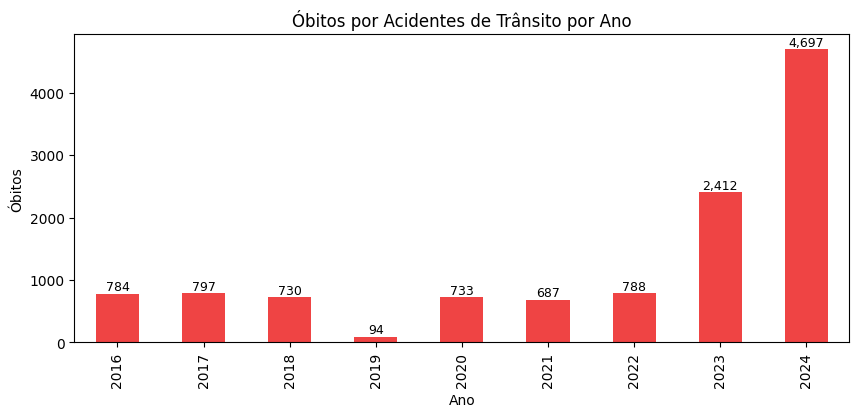

In [40]:
# Gráfico: evolução anual de óbitos
ax = temporal.plot(
    x="ano", y="total_obitos",
    kind="bar", figsize=(10, 4), color="#ef4444",
    title="Óbitos por Acidentes de Trânsito por Ano",
    legend=False
)
ax.set_xlabel("Ano")
ax.set_ylabel("Óbitos")
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=9)

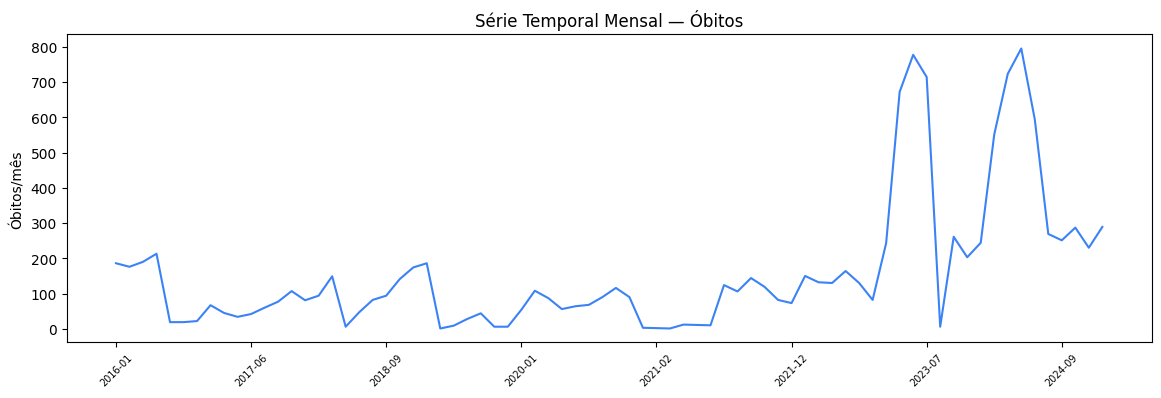

In [41]:
# Série temporal mensal
serie = con.sql("""
    SELECT STRFTIME(competencia, '%Y-%m') AS mes, SUM(total_obitos) AS obitos
    FROM v_obitos
    GROUP BY STRFTIME(competencia, '%Y-%m')
    ORDER BY mes
""").fetchdf()

ax = serie.plot(x="mes", y="obitos", figsize=(14, 4), color="#3b82f6",
                title="Série Temporal Mensal — Óbitos", legend=False)
ax.set_xlabel("")
ax.set_ylabel("Óbitos/mês")
ax.tick_params(axis='x', rotation=45, labelsize=7)

Text(0, 0.5, 'Média de óbitos')

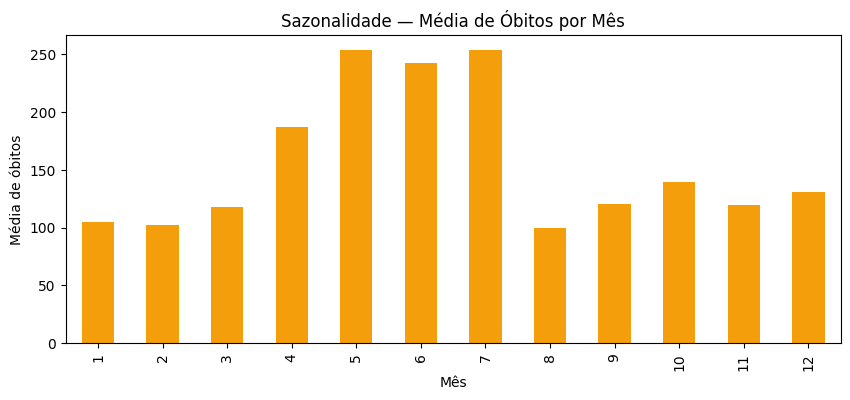

In [42]:
# Sazonalidade mensal (média)
sazon = con.sql("""
    SELECT mes, ROUND(AVG(total), 1) AS media_obitos
    FROM (
        SELECT mes, SUM(total_obitos) AS total
        FROM v_obitos GROUP BY ano, mes
    ) GROUP BY mes ORDER BY mes
""").fetchdf()

ax = sazon.plot(x="mes", y="media_obitos", kind="bar", figsize=(10, 4),
                color="#f59e0b", title="Sazonalidade — Média de Óbitos por Mês", legend=False)
ax.set_xlabel("Mês")
ax.set_ylabel("Média de óbitos")

---

## 3. Distribuições

,tipo_veiculo,total,pct
0,Motociclista,3694.0,31.5
1,Automóvel,3113.0,26.6
2,Outros,3028.0,25.8
3,Pedestre,1392.0,11.9
4,Ciclista,216.0,1.8
5,Veículo pesado,167.0,1.4
6,Ônibus,65.0,0.6
7,Caminhonete,36.0,0.3
8,Triciclo,11.0,0.1


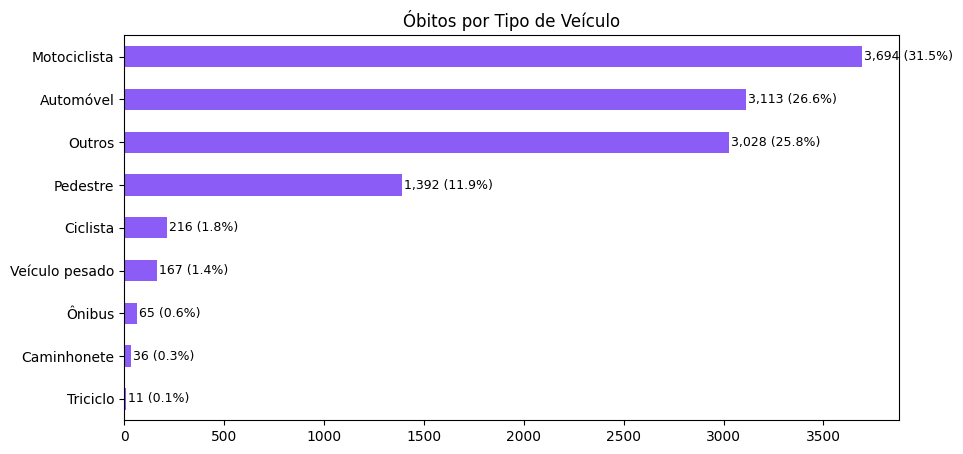

In [43]:
# Por tipo de veículo
tipo = con.sql("""
    SELECT tipo_veiculo, SUM(total_obitos) AS total,
           ROUND(SUM(total_obitos)*100.0 / (SELECT SUM(total_obitos) FROM v_obitos), 1) AS pct
    FROM v_obitos GROUP BY tipo_veiculo ORDER BY total DESC
""").fetchdf()

ax = tipo.plot(x="tipo_veiculo", y="total", kind="barh", figsize=(10, 5),
               color="#8b5cf6", title="Óbitos por Tipo de Veículo", legend=False)
ax.set_ylabel("")
ax.invert_yaxis()
for i, (_, row) in enumerate(tipo.iterrows()):
    ax.text(row['total'] + 10, i, f"{int(row['total']):,} ({row['pct']}%)", va='center', fontsize=9)

tipo

,faixa_etaria,total,pct
0,0-14,341.0,2.9
1,15-24,1897.0,16.2
2,25-34,2356.0,20.1
3,35-44,2473.0,21.1
4,45-54,1893.0,16.1
5,55-64,1393.0,11.9
6,65+,1369.0,11.7


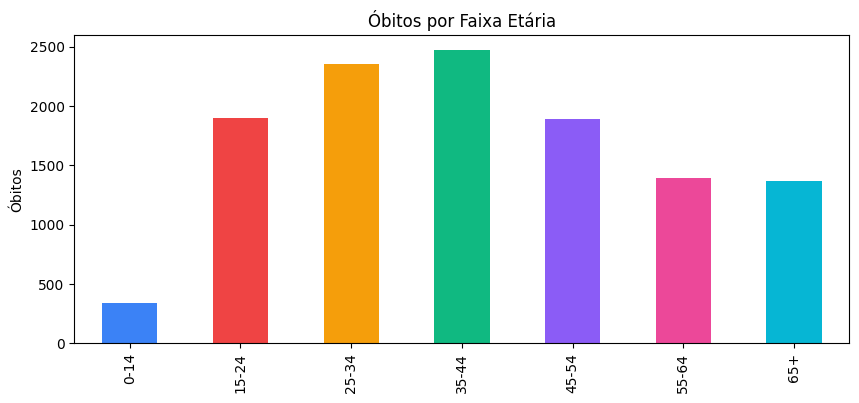

In [44]:
# Por faixa etária
faixa = con.sql("""
    SELECT faixa_etaria, SUM(total_obitos) AS total,
           ROUND(SUM(total_obitos)*100.0 / (SELECT SUM(total_obitos) FROM v_obitos), 1) AS pct
    FROM v_obitos GROUP BY faixa_etaria
    ORDER BY CASE faixa_etaria
        WHEN '0-14' THEN 1 WHEN '15-24' THEN 2 WHEN '25-34' THEN 3
        WHEN '35-44' THEN 4 WHEN '45-54' THEN 5 WHEN '55-64' THEN 6 ELSE 7 END
""").fetchdf()

ax = faixa.plot(x="faixa_etaria", y="total", kind="bar", figsize=(10, 4),
                color=["#3b82f6","#ef4444","#f59e0b","#10b981","#8b5cf6","#ec4899","#06b6d4"],
                title="Óbitos por Faixa Etária", legend=False)
ax.set_xlabel("")
ax.set_ylabel("Óbitos")

faixa

,sexo,total,pct
0,Masculino,9868.0,84.2
1,Feminino,1854.0,15.8


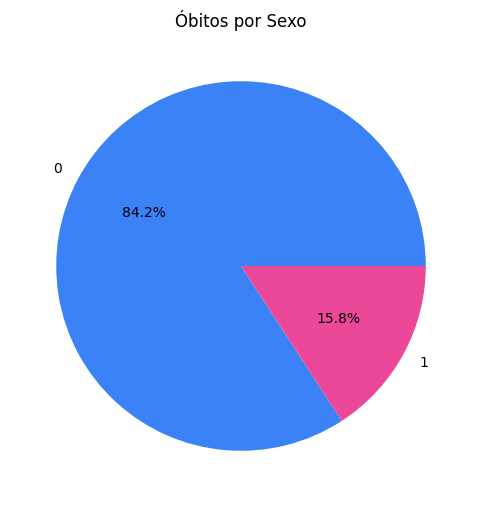

In [45]:
# Por sexo
sexo = con.sql("""
    SELECT sexo, SUM(total_obitos) AS total,
           ROUND(SUM(total_obitos)*100.0 / (SELECT SUM(total_obitos) FROM v_obitos), 1) AS pct
    FROM v_obitos GROUP BY sexo ORDER BY total DESC
""").fetchdf()

sexo.plot(x="sexo", y="total", kind="pie", figsize=(6, 6),
          autopct='%1.1f%%', colors=["#3b82f6", "#ec4899"],
          title="Óbitos por Sexo", legend=False, ylabel="")

sexo

---

## 4. Ranking de Municípios

,municipio,uf,obitos
0,Salvador,BA,940.0
1,Feira de Santana,BA,681.0
2,Vitória da Conquista,BA,554.0
3,Barreiras,BA,384.0
4,Alagoinhas,BA,284.0
5,Guanambi,BA,266.0
6,Santo Antônio de Jesus,BA,255.0
7,Itabuna,BA,216.0
8,Irecê,BA,190.0
9,Jequié,BA,189.0


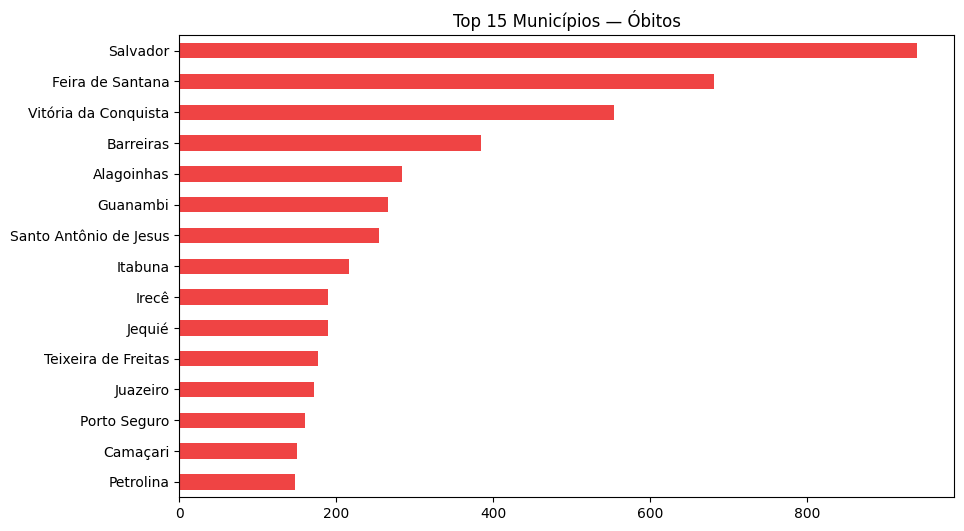

In [46]:
# Top 15 municípios por óbitos
top_mun = con.sql("""
    SELECT municipio, uf, SUM(total_obitos) AS obitos
    FROM v_obitos
    GROUP BY municipio, uf
    ORDER BY obitos DESC
    LIMIT 15
""").fetchdf()

ax = top_mun.plot(x="municipio", y="obitos", kind="barh", figsize=(10, 6),
                  color="#ef4444", title="Top 15 Municípios — Óbitos", legend=False)
ax.set_ylabel("")
ax.invert_yaxis()

top_mun

,municipio,uf,custo_r$,atendimentos
0,Itabuna,BA,65615.96,700.0
1,Salvador,BA,30388.20,1938.0
2,Campo Formoso,BA,18448.74,182.0
3,Camacan,BA,4873.65,47.0
4,Ubaitaba,BA,4623.68,48.0
5,Santo Antônio de Jesus,BA,3462.67,452.0
6,Itajuípe,BA,3290.17,30.0
7,Itapé,BA,3103.16,33.0
8,Ibicaraí,BA,3091.13,27.0
9,Ubatã,BA,2981.14,31.0


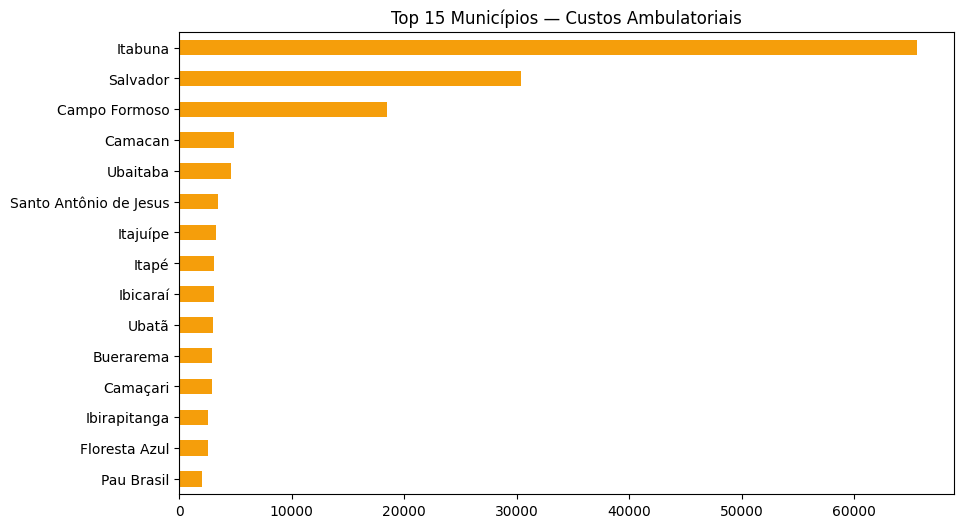

In [47]:
# Top 15 municípios por custos
top_custos = con.sql("""
    SELECT municipio, uf,
           ROUND(SUM(custo_total), 2) AS custo_r$,
           SUM(total_atendimentos) AS atendimentos
    FROM v_custos
    GROUP BY municipio, uf
    ORDER BY custo_r$ DESC
    LIMIT 15
""").fetchdf()

ax = top_custos.plot(x="municipio", y="custo_r$", kind="barh", figsize=(10, 6),
                     color="#f59e0b", title="Top 15 Municípios — Custos Ambulatoriais", legend=False)
ax.set_ylabel("")
ax.invert_yaxis()

top_custos

---

## 5. Análise Detalhada por Município

Troque o `MUNICIPIO` abaixo para explorar qualquer cidade.

Total: 940.0 óbitos em 66 meses


,mes,obitos
0,2016-01,31.0
1,2016-02,26.0
2,2016-03,21.0
3,2016-04,20.0
4,2016-05,1.0
...,...,...
61,2024-08,19.0
62,2024-09,14.0
63,2024-10,16.0
64,2024-11,12.0


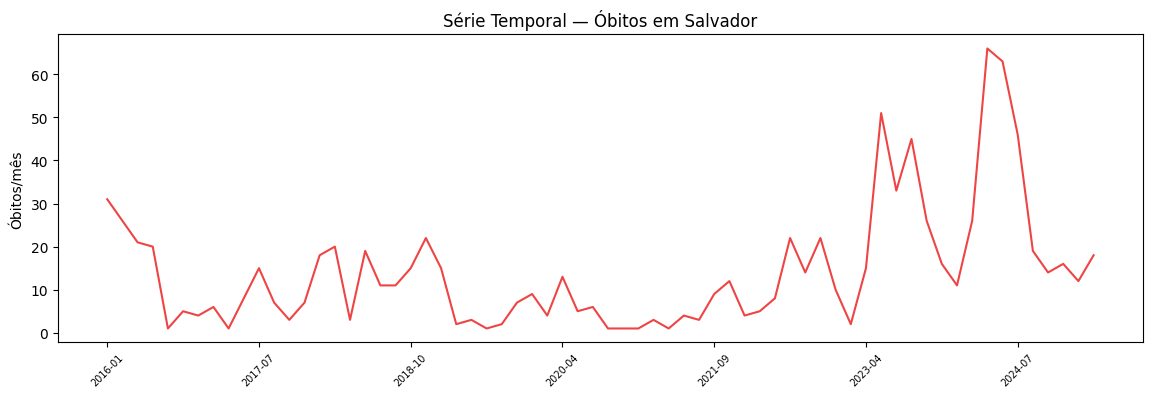

In [48]:
MUNICIPIO = "Salvador"  # <-- troque aqui

detalhe = con.sql(f"""
    SELECT STRFTIME(competencia, '%Y-%m') AS mes, SUM(total_obitos) AS obitos
    FROM v_obitos
    WHERE municipio ILIKE '%{MUNICIPIO}%'
    GROUP BY STRFTIME(competencia, '%Y-%m')
    ORDER BY mes
""").fetchdf()

ax = detalhe.plot(x="mes", y="obitos", figsize=(14, 4), color="#ef4444",
                  title=f"Série Temporal — Óbitos em {MUNICIPIO}", legend=False)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.set_xlabel("")
ax.set_ylabel("Óbitos/mês")

print(f"Total: {detalhe['obitos'].sum():,} óbitos em {len(detalhe)} meses")
detalhe

Total: R$ 30,388.20 em 1,938.0 atendimentos


,mes,custo_r$,atendimentos
0,2018-05,97.44,1.0
1,2018-07,37.95,1.0
2,2019-04,86.76,1.0
3,2020-07,37.95,1.0
4,2021-01,173.51,2.0
5,2021-12,101.10,1.0
6,2022-06,64.80,2.0
7,2022-10,0.00,2.0
8,2023-05,69.48,3.0
9,2023-06,130.20,6.0


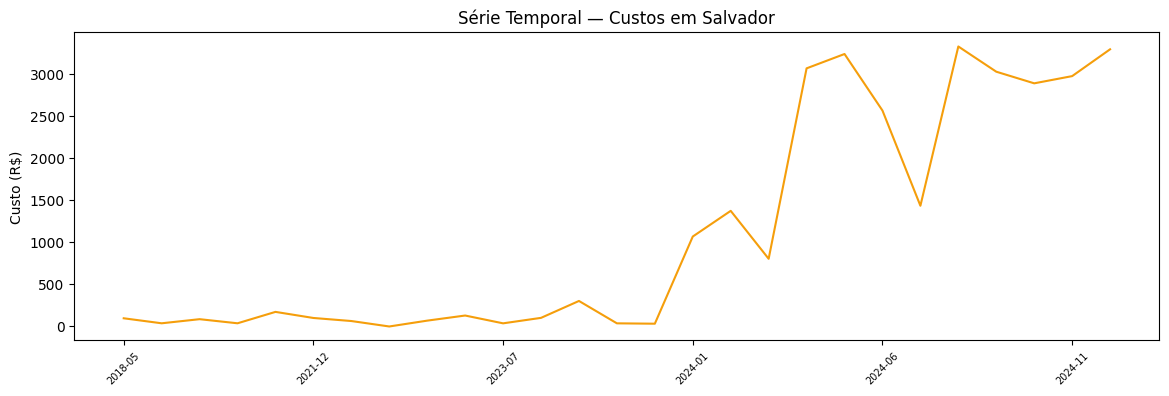

In [49]:
# Custos do município
custos_mun = con.sql(f"""
    SELECT STRFTIME(competencia, '%Y-%m') AS mes,
           ROUND(SUM(custo_total), 2) AS custo_r$,
           SUM(total_atendimentos) AS atendimentos
    FROM v_custos
    WHERE municipio ILIKE '%{MUNICIPIO}%'
    GROUP BY STRFTIME(competencia, '%Y-%m')
    ORDER BY mes
""").fetchdf()

ax = custos_mun.plot(x="mes", y="custo_r$", figsize=(14, 4), color="#f59e0b",
                     title=f"Série Temporal — Custos em {MUNICIPIO}", legend=False)
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.set_xlabel("")
ax.set_ylabel("Custo (R$)")

print(f"Total: R$ {custos_mun['custo_r$'].sum():,.2f} em {custos_mun['atendimentos'].sum():,} atendimentos")
custos_mun

---

## 6. Inspeção das Camadas Bronze e Silver

Para navegar pelas colunas dos dados brutos (antes das transformações).

In [50]:
# Bronze SIM — schema e amostra
sim_source = BRONZE_DIR / "sim_parts"
if not sim_source.exists():
    sim_source = BRONZE_DIR / "sim.parquet"

glob = f"{sim_source}/*.parquet" if sim_source.is_dir() else str(sim_source)
df = con.sql(f"SELECT * FROM read_parquet('{glob}') LIMIT 10").fetchdf()

print(f"Bronze SIM: {con.sql(f"SELECT COUNT(*) FROM read_parquet('{glob}')").fetchone()[0]:,} registros")
print(f"Colunas ({len(df.columns)}): {list(df.columns)}")
df

Bronze SIM: 444,859 registros
Colunas (89): ['CONTADOR', 'ORIGEM', 'TIPOBITO', 'DTOBITO', 'HORAOBITO', 'NATURAL', 'CODMUNNATU', 'DTNASC', 'IDADE', 'SEXO', 'RACACOR', 'ESTCIV', 'ESC', 'ESC2010', 'SERIESCFAL', 'OCUP', 'CODMUNRES', 'LOCOCOR', 'CODESTAB', 'ESTABDESCR', 'CODMUNOCOR', 'IDADEMAE', 'ESCMAE', 'ESCMAE2010', 'SERIESCMAE', 'OCUPMAE', 'QTDFILVIVO', 'QTDFILMORT', 'GRAVIDEZ', 'SEMAGESTAC', 'GESTACAO', 'PARTO', 'OBITOPARTO', 'PESO', 'TPMORTEOCO', 'OBITOGRAV', 'OBITOPUERP', 'ASSISTMED', 'EXAME', 'CIRURGIA', 'NECROPSIA', 'LINHAA', 'LINHAB', 'LINHAC', 'LINHAD', 'LINHAII', 'CAUSABAS', 'CB_PRE', 'CRM', 'COMUNSVOIM', 'DTATESTADO', 'CIRCOBITO', 'ACIDTRAB', 'FONTE', 'NUMEROLOTE', 'TPPOS', 'DTINVESTIG', 'CAUSABAS_O', 'DTCADASTRO', 'ATESTANTE', 'STCODIFICA', 'CODIFICADO', 'VERSAOSIST', 'VERSAOSCB', 'FONTEINV', 'DTRECEBIM', 'ATESTADO', 'DTRECORIGA', 'CAUSAMAT', 'ESCMAEAGR1', 'ESCFALAGR1', 'STDOEPIDEM', 'STDONOVA', 'DIFDATA', 'NUDIASOBCO', 'NUDIASOBIN', 'DTCADINV', 'TPOBITOCOR', 'DTCONINV', 'FONT

,CONTADOR,ORIGEM,TIPOBITO,DTOBITO,HORAOBITO,NATURAL,CODMUNNATU,DTNASC,IDADE,SEXO,...,FONTES,TPRESGINFO,TPNIVELINV,NUDIASINF,DTCADINF,MORTEPARTO,DTCONCASO,FONTESINF,ALTCAUSA,UF
0,1,1,2,01012016,1700,829,292740,01012016,101,1,...,,,,,,,,,,BA
1,2,1,2,01012016,2120,829,292740,25122015,207,2,...,,,,,,,,,,BA
2,3,1,2,01012016,1015,829,291300,08101944,471,1,...,,,,,,,,,,BA
3,4,1,2,01012016,1850,829,292400,22101963,452,1,...,,,,,,,,,,BA
4,5,1,2,01012016,1615,829,292740,25071930,485,2,...,,,,,,,,,,BA
5,6,1,2,01012016,0500,829,291400,05081925,490,1,...,,,,,,,,,,BA
6,7,1,2,01012016,0500,829,291072,09101980,435,1,...,,,,,,,,,,BA
7,8,1,2,01012016,2315,829,292910,04061930,485,1,...,,,,,,,,,,BA
8,9,1,2,01012016,1150,826,261160,16111945,470,1,...,,,,,,,,,,BA
9,10,1,2,01012016,1527,829,291980,20061951,464,2,...,,,,,,,,,,BA


In [51]:
# Bronze SIA — schema e amostra
sia_source = BRONZE_DIR / "sia_parts"
if not sia_source.exists():
    sia_source = BRONZE_DIR / "sia.parquet"

glob_sia = f"{sia_source}/*.parquet" if sia_source.is_dir() else str(sia_source)
df_sia = con.sql(f"SELECT * FROM read_parquet('{glob_sia}') LIMIT 10").fetchdf()

print(f"Bronze SIA: {con.sql(f"SELECT COUNT(*) FROM read_parquet('{glob_sia}')").fetchone()[0]:,} registros")
print(f"Colunas ({len(df_sia.columns)}): {list(df_sia.columns)}")
df_sia

Bronze SIA: 36,171,674 registros
Colunas (61): ['PA_CODUNI', 'PA_GESTAO', 'PA_CONDIC', 'PA_UFMUN', 'PA_REGCT', 'PA_INCOUT', 'PA_INCURG', 'PA_TPUPS', 'PA_TIPPRE', 'PA_MN_IND', 'PA_CNPJCPF', 'PA_CNPJMNT', 'PA_CNPJ_CC', 'PA_MVM', 'PA_CMP', 'PA_PROC_ID', 'PA_TPFIN', 'PA_SUBFIN', 'PA_NIVCPL', 'PA_DOCORIG', 'PA_AUTORIZ', 'PA_CNSMED', 'PA_CBOCOD', 'PA_MOTSAI', 'PA_OBITO', 'PA_ENCERR', 'PA_PERMAN', 'PA_ALTA', 'PA_TRANSF', 'PA_CIDPRI', 'PA_CIDSEC', 'PA_CIDCAS', 'PA_CATEND', 'PA_IDADE', 'IDADEMIN', 'IDADEMAX', 'PA_FLIDADE', 'PA_SEXO', 'PA_RACACOR', 'PA_MUNPCN', 'PA_QTDPRO', 'PA_QTDAPR', 'PA_VALPRO', 'PA_VALAPR', 'PA_UFDIF', 'PA_MNDIF', 'PA_DIF_VAL', 'NU_VPA_TOT', 'NU_PA_TOT', 'PA_INDICA', 'PA_CODOCO', 'PA_FLQT', 'PA_FLER', 'PA_ETNIA', 'PA_VL_CF', 'PA_VL_CL', 'PA_VL_INC', 'PA_SRV_C', 'PA_INE', 'PA_NAT_JUR', 'UF']


,PA_CODUNI,PA_GESTAO,PA_CONDIC,PA_UFMUN,PA_REGCT,PA_INCOUT,PA_INCURG,PA_TPUPS,PA_TIPPRE,PA_MN_IND,...,PA_FLQT,PA_FLER,PA_ETNIA,PA_VL_CF,PA_VL_CL,PA_VL_INC,PA_SRV_C,PA_INE,PA_NAT_JUR,UF
0,6165796,293170,PA,293170,0000,0000,0000,02,00,M,...,K,0,,0.00,0.00,0.00,,,1201,BA
1,6165796,293170,PA,293170,0000,0000,0000,02,00,M,...,K,0,,0.00,0.00,0.00,,,1201,BA
2,6165796,293170,PA,293170,0000,0000,0000,02,00,M,...,K,0,,0.00,0.00,0.00,,,1201,BA
3,2304708,290210,PG,290210,0000,0000,0000,02,00,M,...,K,0,,0.00,0.00,0.00,,,1244,BA
4,2304708,290210,PG,290210,0000,0000,0000,02,00,M,...,K,0,,0.00,0.00,0.00,,,1244,BA
5,2304708,290210,PG,290210,0000,0000,0000,02,00,M,...,K,0,,0.00,0.00,0.00,,,1244,BA
6,2304708,290210,PG,290210,0000,0000,0000,02,00,M,...,K,0,,0.00,0.00,0.00,,,1244,BA
7,2304708,290210,PG,290210,0000,0000,0000,02,00,M,...,K,0,,0.00,0.00,0.00,,,1244,BA
8,2304708,290210,PG,290210,0000,0000,0000,02,00,M,...,K,0,,0.00,0.00,0.00,,,1244,BA
9,2304708,290210,PG,290210,0000,0000,0000,02,00,M,...,K,0,,0.00,0.00,0.00,,,1244,BA


In [52]:
# Silver SIM — após filtro CID V01-V89 e enriquecimento
silver_sim = SILVER_DIR / "sim.parquet"
if silver_sim.exists():
    df_ss = con.sql(f"SELECT * FROM read_parquet('{silver_sim}') LIMIT 10").fetchdf()
    print(f"Silver SIM: {con.sql(f"SELECT COUNT(*) FROM read_parquet('{silver_sim}')").fetchone()[0]:,} registros")
    display(df_ss)
else:
    print("Silver SIM não encontrado. Execute o pipeline ETL.")

Silver SIM: 11,722 registros


,causabas,cid_grupo,dt_obito,competencia,cod_mun_ocorrencia,cod_mun_residencia,sexo,idade,uf,tipo_veiculo,sexo_desc,faixa_etaria
0,V279,V27,2016-01-01,2016-01-01,291370,291050,1,22,BA,Motociclista,Masculino,15-24
1,V031,V03,2016-01-01,2016-01-01,292593,290687,1,49,BA,Pedestre,Masculino,45-54
2,V892,V89,2016-01-01,2016-01-01,290080,293135,2,24,BA,Outros,Feminino,15-24
3,V284,V28,2016-01-01,2016-01-01,280710,292380,1,20,BA,Motociclista,Masculino,15-24
4,V499,V49,2016-01-01,2016-01-01,291950,291950,1,16,BA,Automóvel,Masculino,15-24
5,V299,V29,2016-01-01,2016-01-01,290870,290870,1,24,BA,Motociclista,Masculino,15-24
6,V892,V89,2016-01-01,2016-01-01,290290,290290,1,49,BA,Outros,Masculino,45-54
7,V892,V89,2016-01-01,2016-01-01,290320,290320,1,20,BA,Outros,Masculino,15-24
8,V892,V89,2016-01-01,2016-01-01,290320,290940,1,20,BA,Outros,Masculino,15-24
9,V202,V20,2016-01-02,2016-01-01,292870,290980,1,40,BA,Motociclista,Masculino,35-44


In [53]:
# Silver SIA — após filtro CID V01-V89
silver_sia = SILVER_DIR / "sia.parquet"
if silver_sia.exists():
    df_ss_sia = con.sql(f"SELECT * FROM read_parquet('{silver_sia}') LIMIT 10").fetchdf()
    print(f"Silver SIA: {con.sql(f"SELECT COUNT(*) FROM read_parquet('{silver_sia}')").fetchone()[0]:,} registros")
    display(df_ss_sia)
else:
    print("Silver SIA não encontrado. Execute o pipeline ETL.")

Silver SIA: 4,614 registros


,cid_primario,cid_grupo,cod_mun,datref,competencia,valor_aprovado,qtd_aprovada,sexo,idade,uf,tipo_veiculo,faixa_etaria
0,V280,V28,293070,201608,2016-08-01,97.44,1,F,15,BA,Motociclista,15-24
1,V500,V50,291200,201612,2016-12-01,268.75,1,F,58,BA,Caminhonete,55-64
2,V349,V34,291955,201709,2017-09-01,150.00,1,F,21,BA,Triciclo,15-24
3,V349,V34,291955,201803,2018-03-01,150.00,1,F,26,BA,Triciclo,25-34
4,V349,V34,291955,201803,2018-03-01,150.00,1,F,31,BA,Triciclo,25-34
5,V892,V89,292740,201805,2018-05-01,97.44,1,M,5,BA,Outros,0-14
6,V299,V29,292740,201807,2018-07-01,37.95,1,F,75,BA,Motociclista,65+
7,V298,V29,291370,201810,2018-10-01,97.44,1,M,47,BA,Motociclista,45-54
8,V710,V71,290860,201811,2018-11-01,24.20,1,F,50,BA,Ônibus,45-54
9,V020,V02,291480,201812,2018-12-01,23.16,1,F,6,BA,Pedestre,0-14


---

## 7. Dados IBGE (População e Coordenadas)

In [54]:
# Municípios IBGE com coordenadas
if ibge_mun.exists():
    ibge_df = con.sql("SELECT * FROM v_ibge_municipios ORDER BY nome").fetchdf()
    print(f"IBGE Municípios: {len(ibge_df)} registros")
    display(ibge_df)
else:
    print("ibge_municipios.parquet não encontrado.")

IBGE Municípios: 586 registros


,cod_mun_ibge,nome,uf,regiao,lat,lon
0,2900207,Abaré,BA,Nordeste,-8.8335,-39.3177
1,2900108,Abaíra,BA,Nordeste,-13.2966,-41.7429
2,2900306,Acajutiba,BA,Nordeste,-11.6632,-38.0005
3,2200053,Acauã,PI,Nordeste,-8.3060,-41.0017
4,2900355,Adustina,BA,Nordeste,-10.5623,-38.0376
...,...,...,...,...,...,...
581,2933505,Wenceslau Guimarães,BA,Nordeste,-13.6286,-39.6193
582,2933604,Xique-Xique,BA,Nordeste,-10.9843,-42.7801
583,5100201,Água Boa,MT,Centro-Oeste,-13.9776,-52.5003
584,2900405,Água Fria,BA,Nordeste,-11.8232,-38.7105


In [55]:
# População estimada IBGE
# Verificar caminho para o arquivo parquet com população
if ibge_pop.exists():
    pop_df = con.sql("""
        SELECT p.cod_mun_ibge, m.nome, p.ano, p.populacao
        FROM v_ibge_populacao p
        LEFT JOIN v_ibge_municipios m ON LEFT(p.cod_mun_ibge, 6) = LEFT(m.cod_mun_ibge, 6)
        ORDER BY p.populacao DESC
    """).fetchdf()
    print(f"IBGE População: {len(pop_df)} registros")
    display(pop_df.head(20))
else:
    print("ibge_populacao.parquet não encontrado.")

IBGE População: 1700 registros


,cod_mun_ibge,nome,ano,populacao
0,3304557,Rio de Janeiro,2021,6775561
1,3304557,Rio de Janeiro,2024,6729894
2,5300108,Brasília,2016,2977216
3,2927408,Salvador,2017,2953986
4,2927408,Salvador,2016,2938092
5,2927408,Salvador,2021,2900319
6,2927408,Salvador,2020,2886698
7,2927408,Salvador,2019,2872347
8,2927408,Salvador,2018,2857329
9,2927408,Salvador,2024,2568928


---

## 8. Consultas SQL de Exemplo

Exemplos de consultas que o MCP Server e a API REST usam.

In [56]:
# Exemplo: taxa de mortalidade por 100 mil habitantes
if ibge_pop.exists():
    taxa = con.sql("""
        SELECT
            o.municipio,
            o.uf,
            SUM(o.total_obitos) AS obitos,
            MAX(p.populacao) AS populacao,
            ROUND(SUM(o.total_obitos) * 100000.0 / MAX(p.populacao), 2) AS taxa_100mil
        FROM v_obitos o
        LEFT JOIN v_ibge_populacao p
            ON LEFT(o.cod_mun_ibge, 6) = LEFT(p.cod_mun_ibge, 6)
            AND o.ano = p.ano
        WHERE p.populacao > 0
        GROUP BY o.municipio, o.uf
        ORDER BY taxa_100mil DESC
        LIMIT 15
    """).fetchdf()
    print("Taxa de Mortalidade por 100 mil habitantes:")
    display(taxa)
else:
    print("Sem dados de população. Execute o pipeline com --real para gerar.")

Taxa de Mortalidade por 100 mil habitantes:


,municipio,uf,obitos,populacao,taxa_100mil
0,São José da Vitória,BA,29.0,6081,476.90
1,Gavião,BA,21.0,4493,467.39
2,Irecê,BA,144.0,78425,183.61
3,Guanambi,BA,155.0,93065,166.55
4,Andaraí,BA,22.0,13737,160.15
5,Barreiras,BA,269.0,170667,157.62
6,Santo Antônio de Jesus,BA,171.0,109267,156.50
7,Milagres,BA,18.0,11585,155.37
8,Muquém do São Francisco,BA,17.0,11417,148.90
9,Jacaraci,BA,22.0,14901,147.64


In [57]:
# Exemplo: custo por tipo de veículo em um município
CIDADE = "Feira de Santana"  # <-- troque aqui

custo_tipo = con.sql(f"""
    SELECT tipo_veiculo,
           ROUND(SUM(custo_total), 2) AS custo_r$,
           SUM(total_atendimentos) AS atendimentos
    FROM v_custos
    WHERE municipio ILIKE '%{CIDADE}%'
    GROUP BY tipo_veiculo
    ORDER BY custo_r$ DESC
""").fetchdf()

print(f"Custos por tipo de veículo em {CIDADE}:")
custo_tipo

Custos por tipo de veículo em Feira de Santana:


,tipo_veiculo,custo_r$,atendimentos
0,Outros,107.44,2.0
1,Pedestre,103.06,8.0
2,Motociclista,98.34,7.0
3,Ciclista,31.00,3.0


---

## 9. Limpeza

Feche a conexão ao terminar.

In [58]:
con.close()
print("Conexão DuckDB fechada.")

Conexão DuckDB fechada.
